#Mini-projeto Decision Tree: Titanic Machine Learning from Disaster

**Equipe:**
* Andreywid Yago Lima de Souza
* Artur Vinícius Pereira Fernandes
* Felipe Mateus Falcão Barreto
* João Pedro Mafaldo de Paula
* Matheus Ayres dos Santos


### **Metadados da Base**

**Descrição:**
Esta base de dados é parte da competição "Titanic: Machine Learning from Disaster" da plataforma Kaggle. Ela contém dados demográficos e de viagem de 891 passageiros do RMS Titanic. O objetivo é utilizar esses atributos para construir um modelo de machine learning capaz de prever se um passageiro sobreviveu ou não ao naufrágio.

**Dicionário de Dados**
* **PassengerId**: Um identificador único para cada passageiro.
* **Survived**: A variável alvo que indica se o passageiro sobreviveu (1 = Sim; 0 = Não).
* **Pclass**: A classe socioeconômica da passagem (1 = 1ª Classe; 2 = 2ª Classe; 3 = 3ª Classe).
* **Name**: O nome do passageiro.
* **Sex**: O sexo do passageiro ('male' ou 'female').
* **Age**: A idade do passageiro em anos.
* **SibSp**: O número de irmãos e/ou cônjuges do passageiro a bordo.
* **Parch**: O número de pais e/ou filhos do passageiro a bordo.
* **Ticket**: O número do bilhete da passagem.
* **Fare**: A tarifa paga pela passagem.
* **Cabin**: O número da cabine do passageiro.
* **Embarked**: O porto de embarque (C = Cherbourg; Q = Queenstown; S = Southampton).

# Importação de bibliotecas e base

In [ ]:
# Importação de Bibliotecas Essenciais
import sklearn as skl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

import pandas as pd
import os
import zipfile
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sea
import seaborn as sns
import numpy as np
from functools import partial

!pip install optuna
import optuna

# Montagem do Drive
drive.mount("/content/drive", force_remount=True)
set_of_dfs = {} # Utilizado para validar o impacto de certas alterações, tupla de teste e treino (df_treino, df_test)

# carregamento da base
df_train = pd.read_csv("/content/drive/MyDrive/projetosML/dataset/train.csv")
df_test = pd.read_csv("/content/drive/MyDrive/projetosML/dataset/test.csv") # Teste para colocar no Kaggle, a saida no Kaggle
# df_test_survived = pd.read_csv("/content/drive/MyDrive/projetosML/dataset/gender_submission.csv") #Modelo de saida, como ele espera a resposta no Kaggle

print(f"Shape df_train: {df_train.shape}")
print(f"Shape df_test: {df_test.shape}")
#print(f"Shape df_test_survived: {df_test_survived.shape}")

Mounted at /content/drive
Shape df_train: (891, 12)
Shape df_test: (418, 11)


## Verificação de tipos

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Análise Exploratória

## Análise Univariada

### Variáveis Numéricas (Age e Fare)


In [ ]:
print(df_train[['Age', 'Fare']].describe())

              Age        Fare
count  714.000000  891.000000
mean    29.699118   32.204208
std     14.526497   49.693429
min      0.420000    0.000000
25%     20.125000    7.910400
50%     28.000000   14.454200
75%     38.000000   31.000000
max     80.000000  512.329200


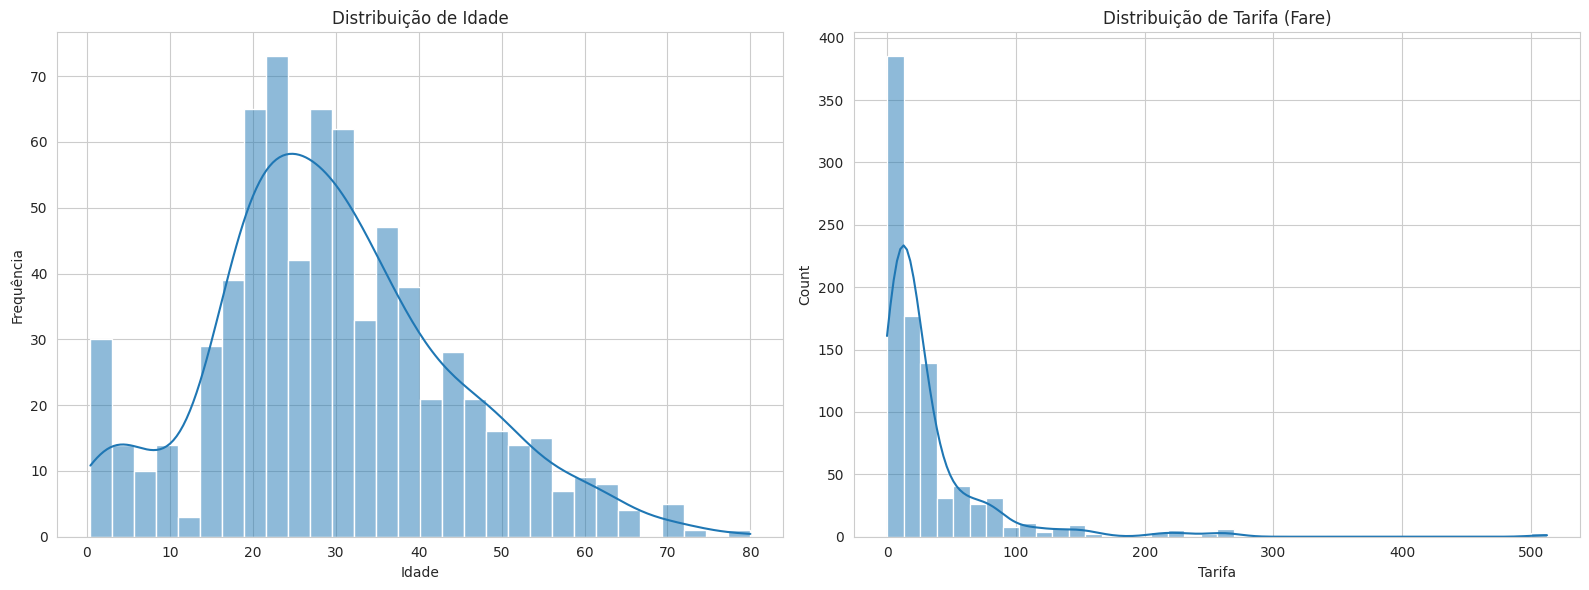

In [ ]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)

sns.histplot(df_train['Age'].dropna(), kde=True, bins=30)
plt.title('Distribuição de Idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
sns.histplot(df_train['Fare'], kde=True, bins=40)
plt.title('Distribuição de Tarifa (Fare)')
plt.xlabel('Tarifa')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Boxplot de Tarifa')

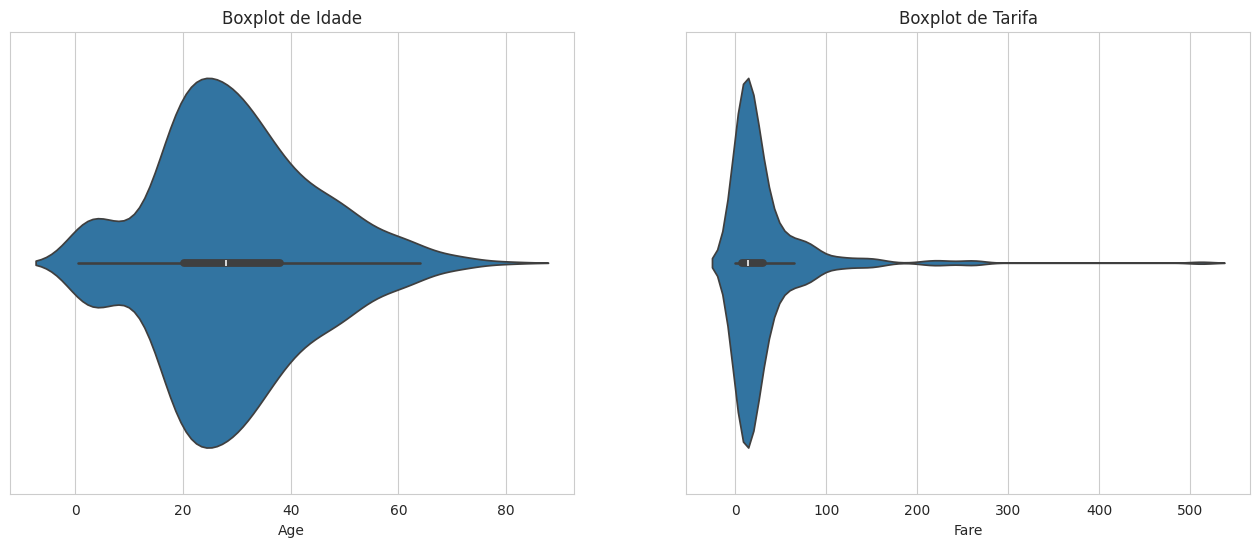

In [ ]:
plt.figure(figsize=(16, 6))

# Boxplot da Idade
plt.subplot(1, 2, 1)
sns.violinplot(x=df_train['Age'])
plt.title('Boxplot de Idade')

# Boxplot da Tarifa
plt.subplot(1, 2, 2)
sns.violinplot(x=df_train['Fare'])
plt.title('Boxplot de Tarifa')

### Variáveis Categóricas

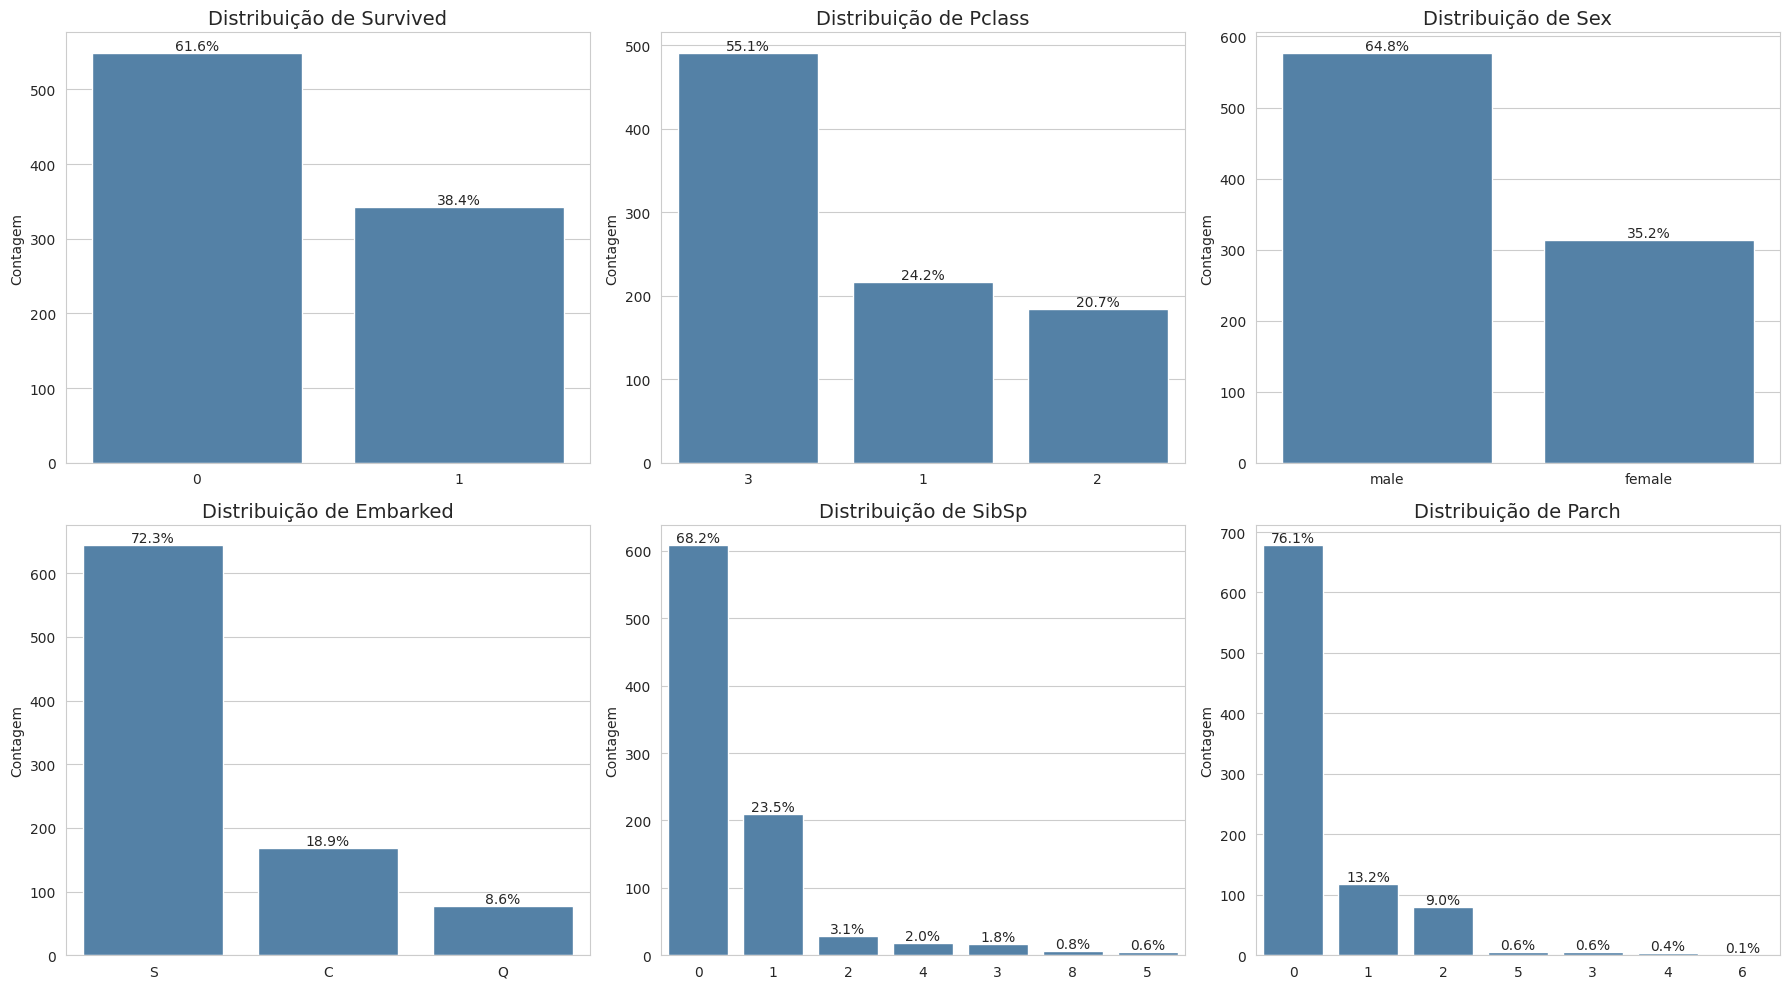

In [ ]:
cols_cate = ['Survived', 'Pclass', 'Sex', 'Embarked', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_cate):
    sns.countplot(
        x=col,
        data=df_train,
        ax=axes[i],
        color='steelblue',
        order=df_train[col].value_counts().index
    )
    axes[i].set_title(f'Distribuição de {col}', fontsize=14)
    axes[i].set_ylabel('Contagem')
    axes[i].set_xlabel('')

    for p in axes[i].patches:
        percentage = f'{100 * p.get_height() / len(df_train):.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        axes[i].annotate(percentage, (x, y), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Análise bivariada

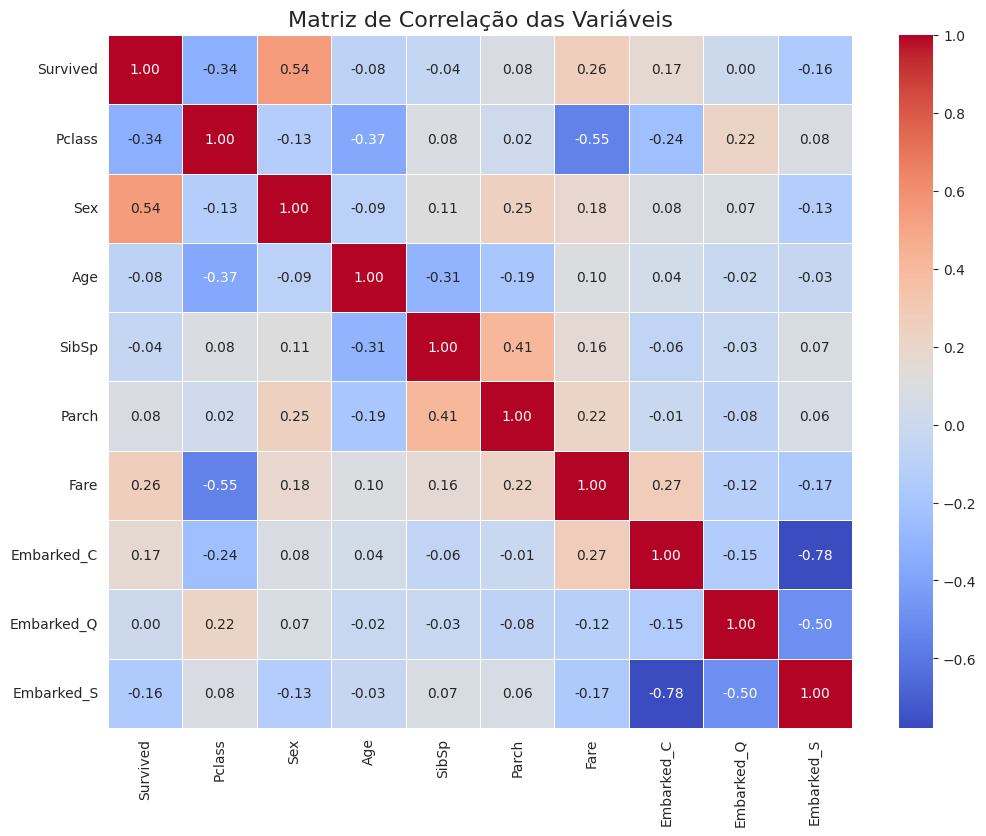

In [ ]:
df_corr = df_train.copy()

# colunas que não têm valor para a correlação.
df_corr.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)


df_corr['Sex'] = df_corr['Sex'].map({'male': 0, 'female': 1})
# One-Hot Encoding para 'Embarked'
df_corr = pd.get_dummies(df_corr, columns=['Embarked'], prefix='Embarked', drop_first=False)

correlation_matrix = df_corr.corr()

# heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5
)
plt.title('Matriz de Correlação das Variáveis', fontsize=16)
plt.show()

### Variáveis Numéricas vs Sobrevivência

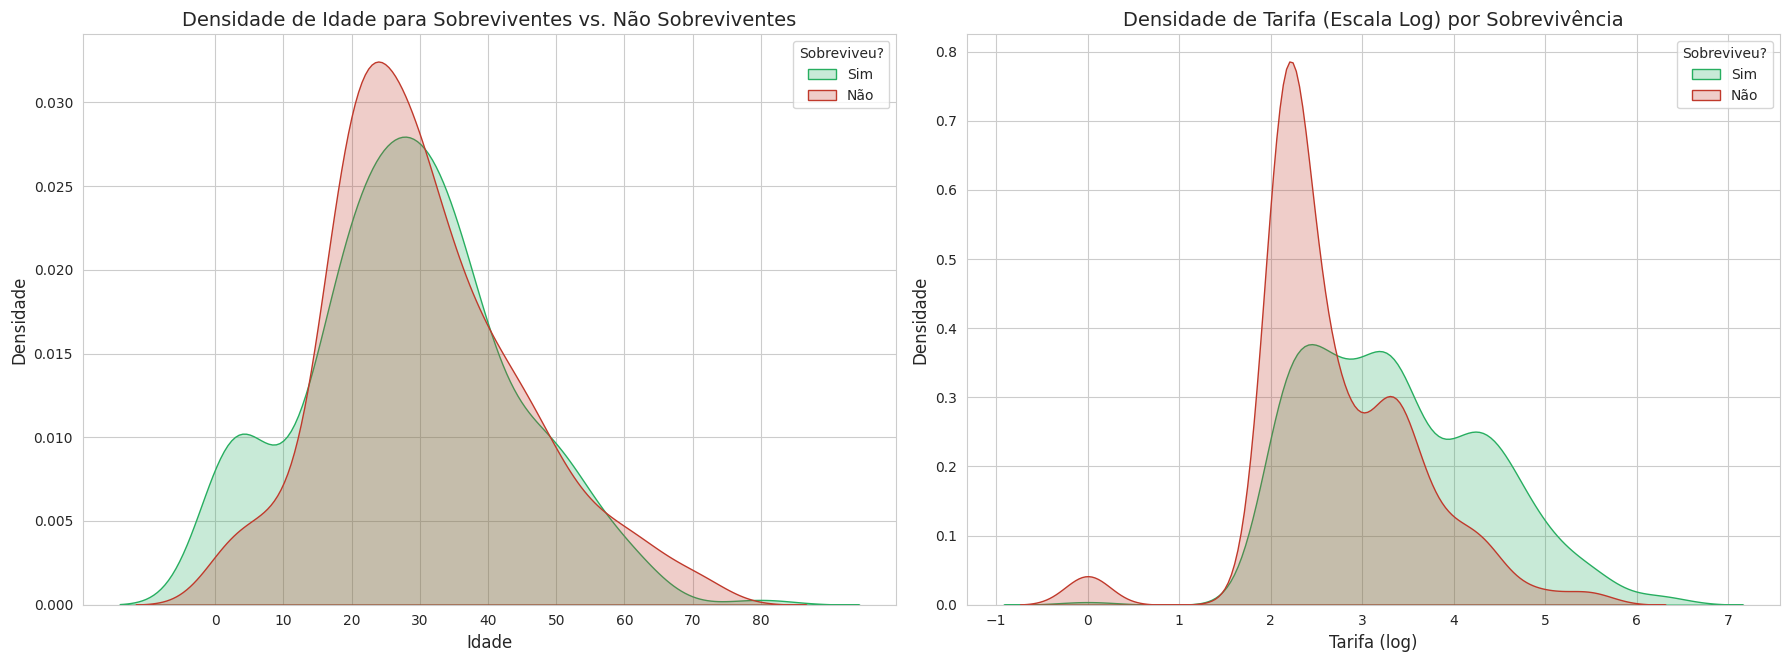

In [ ]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sobrevivencia_palette = {0: "#c0392b", 1: "#27ae60"}

# Gráfico de Densidade para Idade
sns.kdeplot(
    data=df_train,
    x='Age',
    hue='Survived',
    ax=axes[0],
    palette=sobrevivencia_palette,
    fill=True,
    common_norm=False
)
axes[0].set_title('Densidade de Idade para Sobreviventes vs. Não Sobreviventes', fontsize=14)
axes[0].set_xlabel('Idade', fontsize=12)
axes[0].set_ylabel('Densidade', fontsize=12)
axes[0].legend(title='Sobreviveu?', labels=['Sim', 'Não'])

axes[0].set_xticks(np.arange(0, 90, 10))

# Gráfico de Densidade para Tarifa em Escala Logarítmica
# Aplicamos (log(1+x)) para tratar a assimetria e os valores zero da tarifa
df_train['Fare_log'] = np.log1p(df_train['Fare'])

sns.kdeplot(
    data=df_train,
    x='Fare_log',
    hue='Survived',
    ax=axes[1],
    palette=sobrevivencia_palette,
    fill=True,
    common_norm=False
)
axes[1].set_title('Densidade de Tarifa (Escala Log) por Sobrevivência', fontsize=14)
axes[1].set_xlabel('Tarifa (log)', fontsize=12)
axes[1].set_ylabel('Densidade', fontsize=12)
axes[1].legend(title='Sobreviveu?', labels=['Sim', 'Não'])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

df_train.drop(columns=['Fare_log'], inplace=True)

### Variáveis Categóricas vs Sobrevivência

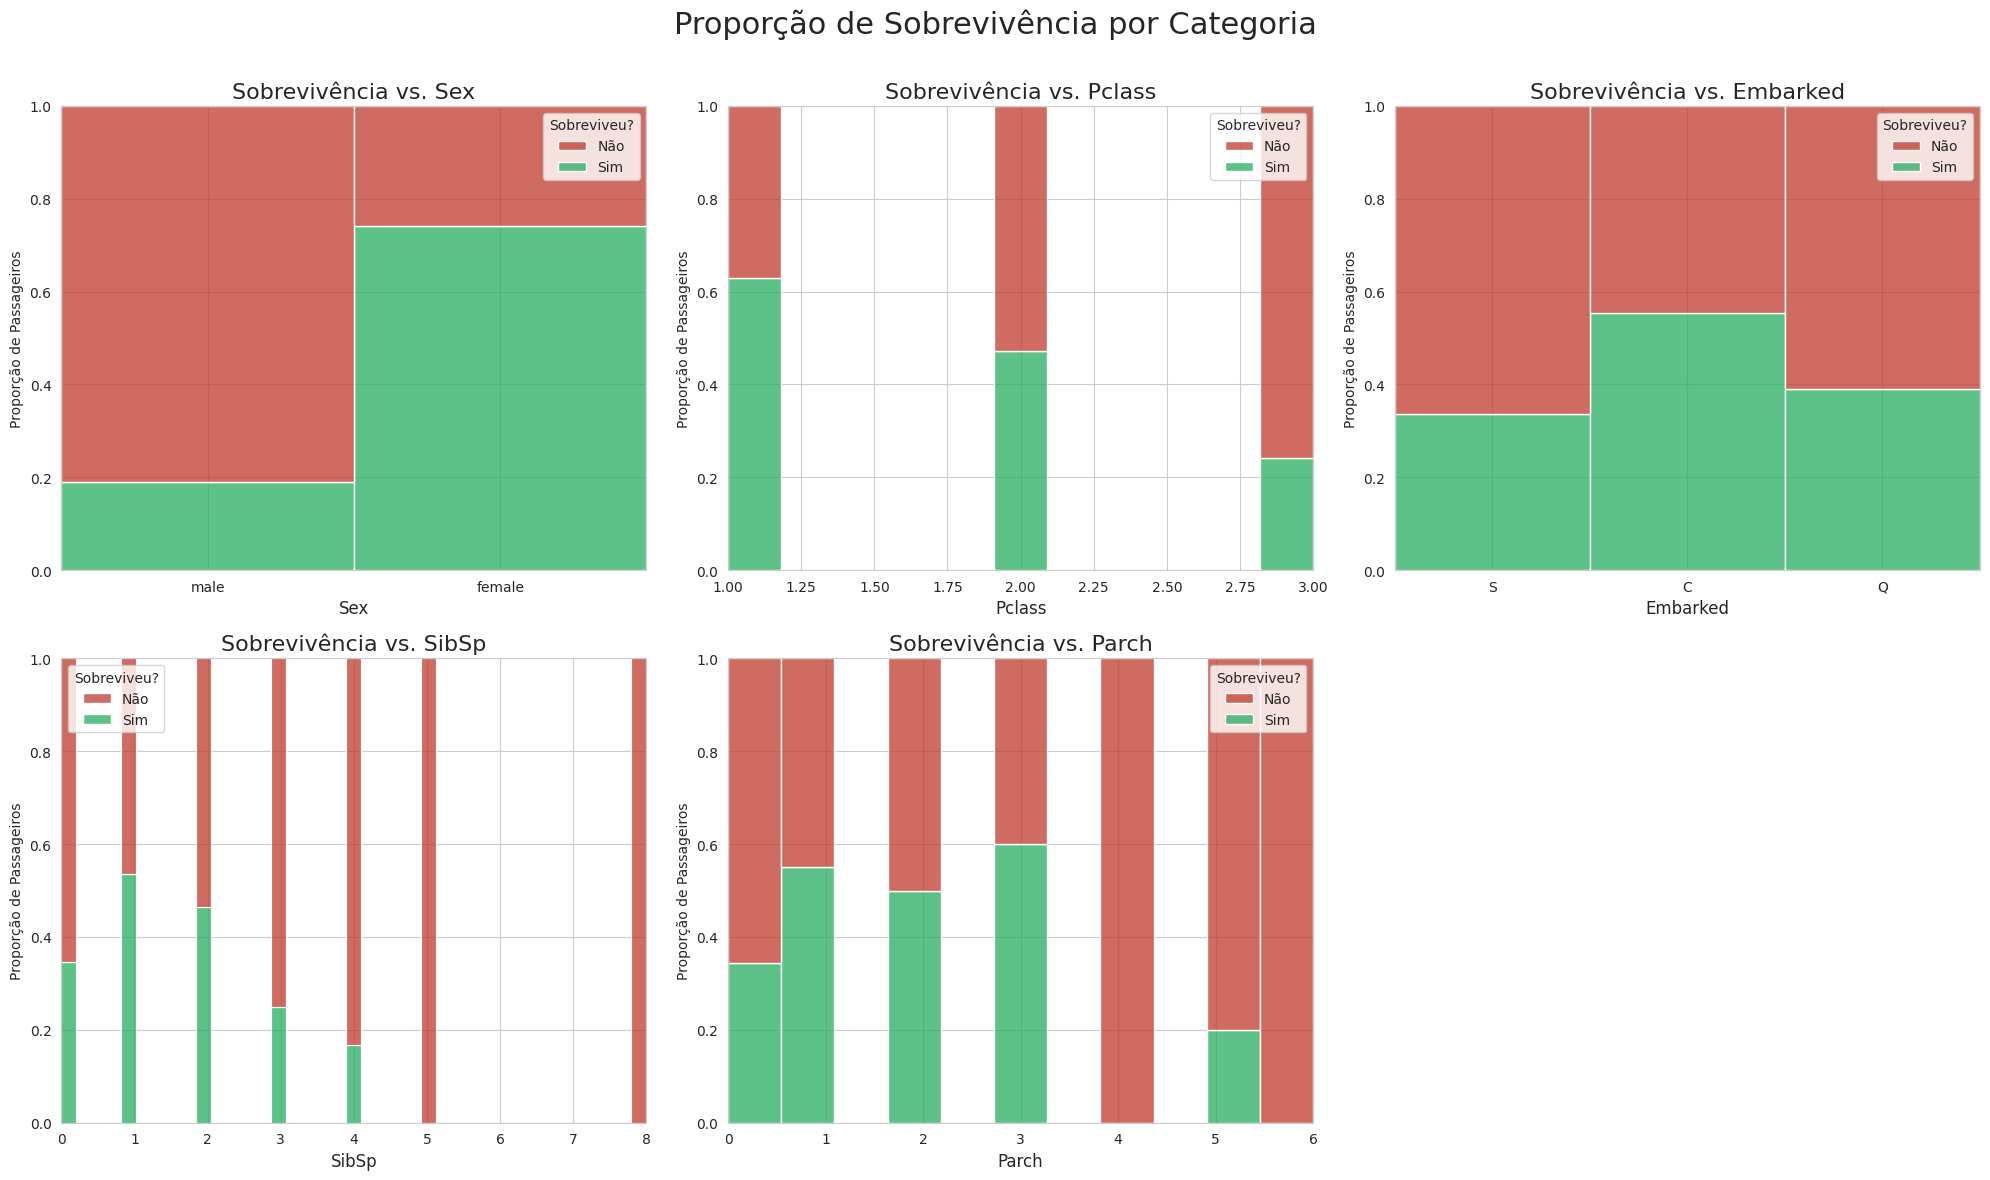

In [ ]:
sns.set_style("whitegrid")

cat_cols_bivariate = ['Sex', 'Pclass', 'Embarked', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Proporção de Sobrevivência por Categoria', fontsize=22)

axes = axes.flatten()

sobrevivencia_palette = {0: "#c0392b", 1: "#27ae60"}

for i, col in enumerate(cat_cols_bivariate):
    sns.histplot(
        data=df_train,
        x=col,
        hue='Survived',
        multiple='fill',
        palette=sobrevivencia_palette,
        ax=axes[i],

    )
    axes[i].set_title(f'Sobrevivência vs. {col}', fontsize=16)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Proporção de Passageiros')

    legend = axes[i].get_legend()
    if legend:
        legend.set_title('Sobreviveu?')
        new_labels = ['Não', 'Sim']
        for t, l in zip(legend.texts, new_labels):
            t.set_text(l)

axes[5].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

#Pré-Processamento e Preparação dos Dados.

In [ ]:
# Separando as features (X) da variável alvo (y)
X = df_train.drop('Survived', axis=1)
y = df_train['Survived']

# Primeira divisão: 50% para Treino
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.50,
    random_state=42,
    stratify=y
)
# Segunda divisão: 25% para Validação e 25% para Teste.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

total_len = len(df_train)
print(f"conjunto de Treino: {len(X_train)}")
print(f"conjunto de Validação: {len(X_val)}")
print(f"conjunto de Teste: {len(X_test)}")

conjunto de Treino: 445
conjunto de Validação: 223
conjunto de Teste: 223


## Tratamento de valores ausentes

In [ ]:
print("Nulos em X_train:\n", X_train.isnull().sum())
print("\nNulos em X_val:\n", X_val.isnull().sum())
print("\nNulos em X_test:\n", X_test.isnull().sum())

Nulos em X_train:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             91
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          346
Embarked         1
dtype: int64

Nulos em X_val:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             37
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          173
Embarked         0
dtype: int64

Nulos em X_test:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             49
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          168
Embarked         1
dtype: int64


### Tratamento da coluna 'Cabin'

In [ ]:
# Transformando em "Has_Cabin"
Xs = [X_train, X_test, X_val]

for i, X in enumerate(Xs):
    not_null_value = X["Cabin"].notna()
    cabins = X["Cabin"].copy()
    cabins[not_null_value] = 1
    cabins[~not_null_value] = 0

    X["Cabin"] = cabins
    X = X.rename(columns = {"Cabin":"Has_Cabin"})
    #X só cria um temp para o valor de Xs, precisa dessa linha para atualizar
    Xs[i] = X
X_train, X_test, X_val = Xs

### Tratamento da coluna 'Age'

In [ ]:
# Calcula a mediana por sexo usando apenas X_train
age_median_by_sex = X_train.groupby('Sex')['Age'].median()

print(age_median_by_sex)

Sex
female    29.0
male      30.0
Name: Age, dtype: float64


In [ ]:
# Preenche os valores nulos usando a mediana de X_train por sexo
X_train['Age'] = X_train['Age'].fillna(X_train['Sex'].map(age_median_by_sex))
X_val['Age'] = X_val['Age'].fillna(X_val['Sex'].map(age_median_by_sex))
X_test['Age'] = X_test['Age'].fillna(X_test['Sex'].map(age_median_by_sex))

### Tratamento da coluna 'Embarked'


In [ ]:
embarked_mode = X_train['Embarked'].mode()[0]
print(f"A moda de embarque de X_train: '{embarked_mode}'")

A moda de embarque de X_train: 'S'


In [ ]:
# Aplicando a moda
X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)
X_val['Embarked'] = X_val['Embarked'].fillna(embarked_mode)
X_test['Embarked'] = X_test['Embarked'].fillna(embarked_mode)

## Codificação de Variáveis Categóricas

In [ ]:
# removendo colunas muitos valores únicos
X_train.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
X_val.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
X_test.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

In [ ]:
# Mapeamento Binário da coluna 'Sex'
sex_map = {'male': 0, 'female': 1}

X_train['Sex'] = X_train['Sex'].map(sex_map)
X_val['Sex'] = X_val['Sex'].map(sex_map)
X_test['Sex'] = X_test['Sex'].map(sex_map)

In [ ]:
# One-Hot Encoding da coluna 'Embarked'
X_train = pd.get_dummies(X_train, columns=['Embarked'], prefix='Embarked', dtype=int)
X_val = pd.get_dummies(X_val, columns=['Embarked'], prefix='Embarked', dtype=int)
X_test = pd.get_dummies(X_test, columns=['Embarked'], prefix='Embarked', dtype=int)

In [ ]:
# Verificando nossa train
print(X_train.info())
print(X_train.head())

<class 'pandas.core.frame.DataFrame'>
Index: 445 entries, 652 to 28
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      445 non-null    int64  
 1   Sex         445 non-null    int64  
 2   Age         445 non-null    float64
 3   SibSp       445 non-null    int64  
 4   Parch       445 non-null    int64  
 5   Fare        445 non-null    float64
 6   Has_Cabin   445 non-null    object 
 7   Embarked_C  445 non-null    int64  
 8   Embarked_Q  445 non-null    int64  
 9   Embarked_S  445 non-null    int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 38.2+ KB
None
     Pclass  Sex   Age  SibSp  Parch      Fare Has_Cabin  Embarked_C  \
652       3    0  21.0      0      0    8.4333         0           0   
550       1    0  17.0      0      2  110.8833         1           1   
254       3    1  41.0      0      2   20.2125         0           0   
24        3    1   8.0      3      1   21.0750     

## Criação de coluna sobre quantidade de parentes à bordo

In [ ]:
Xs = [X_train, X_test, X_val]

for i, X in enumerate(Xs):
    family_size = X["SibSp"] + X["Parch"] + 1
    X["Relatives"] = family_size
    X = X.drop(columns = ["SibSp", "Parch"])
    Xs[i] = X

X_train, X_test, X_val = Xs


In [ ]:
print(X_train.columns)

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Has_Cabin', 'Embarked_C', 'Embarked_Q',
       'Embarked_S', 'Relatives'],
      dtype='object')


## Normalização dos Dados

In [ ]:
# Inicialização
scaler = MinMaxScaler()

# Aprendendo a escala os dados de treino
scaler.fit(X_train)

# Aplicando a transformação
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [ ]:
# Checando a escala dos dados
print(X_train_scaled.head())
print(X_train_scaled.describe().loc[['min', 'max']])

     Pclass  Sex       Age      Fare  Has_Cabin  Embarked_C  Embarked_Q  \
652     1.0  0.0  0.258608  0.016461        0.0         0.0         0.0   
550     0.0  0.0  0.208344  0.216430        1.0         1.0         0.0   
254     1.0  1.0  0.509927  0.039452        0.0         0.0         0.0   
24      1.0  1.0  0.095250  0.041136        0.0         0.0         0.0   
434     0.0  0.0  0.623021  0.109110        1.0         0.0         0.0   

     Embarked_S  Relatives  
652         1.0        0.0  
550         0.0        0.2  
254         1.0        0.2  
24          1.0        0.4  
434         1.0        0.1  
     Pclass  Sex  Age  Fare  Has_Cabin  Embarked_C  Embarked_Q  Embarked_S  \
min     0.0  0.0  0.0   0.0        0.0         0.0         0.0         0.0   
max     1.0  1.0  1.0   1.0        1.0         1.0         1.0         1.0   

     Relatives  
min        0.0  
max        1.0  


# Modelagem e Avaliação

##Árvore de Decisão

In [ ]:
random_state = 20

### Descrição
Neste primeiro experimento, utilizamos uma árvore de decisão com o critério 'gini' e hiperparâmetros definidos arbitrariamente. O objetivo foi estabelecer uma linha de base (baseline) para a performance do modelo, com `max_depth` de 5, `min_samples_split` de 10 e `min_samples_leaf` de 4. A acurácia no conjunto de validação foi de 78.92%.

### Experimento 0

In [ ]:
# Decision tree padrão com gini e parametros arbitrarios
tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight = "balanced",
    random_state = random_state
)

In [ ]:
tree.fit(X_train_scaled, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       max_features='sqrt', min_samples_leaf=4,
                       min_samples_split=10, random_state=20)

In [ ]:
# Fazendo previsões nos dados de treino
y_pred_train = tree.predict(X_train_scaled)
# Fazendo previsões nos dados de validação
y_pred_val = tree.predict(X_val_scaled)

In [ ]:
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_val = accuracy_score(y_val, y_pred_val)

print(f"Acurácia no conjunto de TREINO: {accuracy_train * 100:.2f}%")
print(f"Acurácia no conjunto de VALIDAÇÃO: {accuracy_val * 100:.2f}%")

Acurácia no conjunto de TREINO: 82.02%
Acurácia no conjunto de VALIDAÇÃO: 78.92%


### Descrição

No segundo experimento, trocamos o critério de 'gini' para 'entropy', mantendo os mesmos hiperparâmetros do experimento anterior. Essa mudança resultou em uma melhora na acurácia de validação para 81.17%, indicando que a entropia como medida de impureza pode ser mais eficaz para este conjunto de dados.

### Experimento 1


In [ ]:
# Decision tree padrão com Entropy de critério
tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight = "balanced",

    random_state = random_state
)

In [ ]:
tree.fit(X_train_scaled, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, max_features='sqrt', min_samples_leaf=4,
                       min_samples_split=10, random_state=20)

In [ ]:
# Fazendo previsões nos dados de treino
y_pred_train = tree.predict(X_train_scaled)
# Fazendo previsões nos dados de validação
y_pred_val = tree.predict(X_val_scaled)

In [ ]:
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_val = accuracy_score(y_val, y_pred_val)

print(f"Acurácia no conjunto de TREINO: {accuracy_train * 100:.2f}%")
print(f"Acurácia no conjunto de VALIDAÇÃO: {accuracy_val * 100:.2f}%")

Acurácia no conjunto de TREINO: 80.00%
Acurácia no conjunto de VALIDAÇÃO: 81.17%


### Descrição
Aumentamos a complexidade da árvore, elevando `max_depth` para 8 e `min_samples_split` para 20. A intenção era verificar se um modelo mais complexo capturaria melhor os padrões dos dados. A acurácia de validação teve uma ligeira queda para 80.72%, sugerindo um possível início de sobreajuste (overfitting).

### Experimento 2


In [ ]:
# Decision tree padrão com Entropy e numero de samples minimos maior
tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state = random_state,
    class_weight = "balanced",

)

In [ ]:
tree.fit(X_train_scaled, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=8, max_features='sqrt', min_samples_leaf=4,
                       min_samples_split=20, random_state=20)

In [ ]:
# Fazendo previsões nos dados de treino
y_pred_train = tree.predict(X_train_scaled)
# Fazendo previsões nos dados de validação
y_pred_val = tree.predict(X_val_scaled)

In [ ]:
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_val = accuracy_score(y_val, y_pred_val)

print(f"Acurácia no conjunto de TREINO: {accuracy_train * 100:.2f}%")
print(f"Acurácia no conjunto de VALIDAÇÃO: {accuracy_val * 100:.2f}%")

Acurácia no conjunto de TREINO: 82.70%
Acurácia no conjunto de VALIDAÇÃO: 80.72%


### Descrição

Mantivemos `max_depth` em 8, mas reduzimos `min_samples_split` de volta para 10, buscando um equilíbrio entre a complexidade do modelo e a capacidade de generalização. O resultado foi a melhor acurácia de validação até então, com 82.96%, mostrando que uma árvore mais profunda, mas com um número menor de amostras para divisão, foi benéfica.

### Experimento 3



In [ ]:
# Decision tree padrão com Entropy e com uma profundidade maior
tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight = "balanced",
    random_state = random_state

)

In [ ]:
tree.fit(X_train_scaled, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=8, max_features='sqrt', min_samples_leaf=4,
                       min_samples_split=10, random_state=20)

In [ ]:
# Fazendo previsões nos dados de treino
y_pred_train = tree.predict(X_train_scaled)
# Fazendo previsões nos dados de validação
y_pred_val = tree.predict(X_val_scaled)

In [ ]:
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_val = accuracy_score(y_val, y_pred_val)

print(f"Acurácia no conjunto de TREINO: {accuracy_train * 100:.2f}%")
print(f"Acurácia no conjunto de VALIDAÇÃO: {accuracy_val * 100:.2f}%")

Acurácia no conjunto de TREINO: 85.84%
Acurácia no conjunto de VALIDAÇÃO: 82.96%


### Descrição

Para investigar o efeito da profundidade, reduzimos `max_depth` para 4. Como esperado, a acurácia de validação caiu para 79.37%, confirmando que uma árvore muito simples não consegue capturar a complexidade necessária dos dados.

### Experimento 4


In [ ]:
# Decision tree padrão com Entropy e menor profundidade
tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state = random_state,
    class_weight = "balanced",

)

In [ ]:
tree.fit(X_train_scaled, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=4, max_features='sqrt', min_samples_leaf=4,
                       min_samples_split=10, random_state=20)

In [ ]:
# Fazendo previsões nos dados de treino
y_pred_train = tree.predict(X_train_scaled)
# Fazendo previsões nos dados de validação
y_pred_val = tree.predict(X_val_scaled)

In [ ]:
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_val = accuracy_score(y_val, y_pred_val)

print(f"Acurácia no conjunto de TREINO: {accuracy_train * 100:.2f}%")
print(f"Acurácia no conjunto de VALIDAÇÃO: {accuracy_val * 100:.2f}%")

Acurácia no conjunto de TREINO: 77.98%
Acurácia no conjunto de VALIDAÇÃO: 79.37%


### Descrição
Neste experimento, utilizamos o `RandomForestClassifier`, um modelo de ensemble que combina várias árvores de decisão. Usamos os melhores hiperparâmetros encontrados para a árvore de decisão única (`max_depth`=8, `min_samples_split`=10, `min_samples_leaf`=4). A acurácia de validação ficou em 82.51%, um pouco abaixo do melhor resultado com uma única árvore, mas com um potencial maior de generalização.

### Experimento 5


In [ ]:
# Random forest com os melhores parametros encontrados até o momento
# Consideram varias árvores em parelelo, extraindo o melhor delas.
tree = RandomForestClassifier(
    criterion='entropy',
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight = "balanced",

    random_state = random_state
)

In [ ]:
tree.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=8, min_samples_leaf=4, min_samples_split=10,
                       random_state=20)

In [ ]:
# Fazendo previsões nos dados de treino
y_pred_train = tree.predict(X_train_scaled)
# Fazendo previsões nos dados de validação
y_pred_val = tree.predict(X_val_scaled)

In [ ]:
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_val = accuracy_score(y_val, y_pred_val)

print(f"Acurácia no conjunto de TREINO: {accuracy_train * 100:.2f}%")
print(f"Acurácia no conjunto de VALIDAÇÃO: {accuracy_val * 100:.2f}%")

Acurácia no conjunto de TREINO: 88.54%
Acurácia no conjunto de VALIDAÇÃO: 82.51%


### Descrição
Por fim, testamos o `GradientBoostingClassifier`, outro modelo de ensemble que constrói árvores de forma sequencial, onde cada árvore corrige os erros da anterior. Com `max_depth` de 8 e `min_samples_split` de 20, alcançamos a maior acurácia de validação até o momento, com 86.10%, demonstrando a superioridade do boosting para este problema.

### Experimento 6


In [ ]:
# Random forest com os melhores parametros encontrados até o momento
# Consideram varias árvores em parelelo, extraindo o melhor delas.
tree = GradientBoostingClassifier(
    criterion='squared_error',
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state = random_state,

)

In [ ]:
tree.fit(X_train_scaled, y_train)

GradientBoostingClassifier(criterion='squared_error', max_depth=8,
                           max_features='sqrt', min_samples_leaf=4,
                           min_samples_split=20, random_state=20)

In [ ]:
# Fazendo previsões nos dados de treino
y_pred_train = tree.predict(X_train_scaled)
# Fazendo previsões nos dados de validação
y_pred_val = tree.predict(X_val_scaled)

In [ ]:
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_val = accuracy_score(y_val, y_pred_val)

print(f"Acurácia no conjunto de TREINO: {accuracy_train * 100:.2f}%")
print(f"Acurácia no conjunto de VALIDAÇÃO: {accuracy_val * 100:.2f}%")

Acurácia no conjunto de TREINO: 98.20%
Acurácia no conjunto de VALIDAÇÃO: 86.10%


###Grid Search

In [ ]:
results = []

# DECISION TREE - grade enxuta
dt_grid = {
    'max_depth': [4, 5, 8],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [4, 6],
    'max_features': ['sqrt', None],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced'],
}

dt_model = DecisionTreeClassifier(random_state=random_state)
dt_search = GridSearchCV(dt_model, dt_grid, cv=3, scoring='accuracy', n_jobs=-1)
dt_search.fit(X_train_scaled, y_train)

best_dt = dt_search.best_estimator_
print(f"\nDecision Tree melhores params: {dt_search.best_params_}")

results.append({
    'model': 'DecisionTree',
    'train_acc': accuracy_score(y_train, best_dt.predict(X_train_scaled)),
    'val_acc': accuracy_score(y_val, best_dt.predict(X_val_scaled)),
    'params': dt_search.best_params_
})

# RANDOM FOREST - grade enxuta
rf_grid = {
    'max_depth': [4, 5, 8],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [4, 6],
    'max_features': ['sqrt', None],
    'criterion': ['gini'],
    'class_weight': ['balanced'],
    'n_estimators': [50, 100],
}

rf_model = RandomForestClassifier(random_state=random_state, n_jobs=-1)
rf_search = GridSearchCV(rf_model, rf_grid, cv=3, scoring='accuracy', n_jobs=-1)
rf_search.fit(X_train_scaled, y_train)

best_rf = rf_search.best_estimator_
print(f"\nRandom Forest melhores params: {rf_search.best_params_}")

results.append({
    'model': 'RandomForest',
    'train_acc': accuracy_score(y_train, best_rf.predict(X_train_scaled)),
    'val_acc': accuracy_score(y_val, best_rf.predict(X_val_scaled)),
    'params': rf_search.best_params_
})

# GRADIENT BOOSTING - grade enxuta
gb_grid = {
    'max_depth': [4, 5, 8],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [4, 6],
    'max_features': ['sqrt', None],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [50, 100],
}

gb_model = GradientBoostingClassifier(random_state=random_state)
gb_search = GridSearchCV(gb_model, gb_grid, cv=3, scoring='accuracy', n_jobs=-1)
gb_search.fit(X_train_scaled, y_train)

best_gb = gb_search.best_estimator_
print(f"\nGradient Boosting melhores params: {gb_search.best_params_}")

results.append({
    'model': 'GradientBoosting',
    'train_acc': accuracy_score(y_train, best_gb.predict(X_train_scaled)),
    'val_acc': accuracy_score(y_val, best_gb.predict(X_val_scaled)),
    'params': gb_search.best_params_
})


Decision Tree melhores params: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 20}

Random Forest melhores params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 8, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 100}

Gradient Boosting melhores params: {'learning_rate': 0.1, 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 20, 'n_estimators': 50}


In [ ]:

# Resultados finais
for r in results:
    print(f"\nModelo: {r['model']}")
    print(f"Acurácia TREINO: {r['train_acc']*100:.2f}%")
    print(f"Acurácia VALIDAÇÃO: {r['val_acc']*100:.2f}%")
    print(f"Hiperparâmetros: {r['params']}")



Modelo: DecisionTree
Acurácia TREINO: 82.25%
Acurácia VALIDAÇÃO: 78.48%
Hiperparâmetros: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 20}

Modelo: RandomForest
Acurácia TREINO: 87.42%
Acurácia VALIDAÇÃO: 82.51%
Hiperparâmetros: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 8, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 100}

Modelo: GradientBoosting
Acurácia TREINO: 92.13%
Acurácia VALIDAÇÃO: 86.10%
Hiperparâmetros: {'learning_rate': 0.1, 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 20, 'n_estimators': 50}


###Optuna

Treinamento focado nos experimentos anteriores com alguns dados extras para treinamento

In [ ]:
def objective(trial):
    tree_name = trial.suggest_categorical('model', ['DecisionTree', 'RandomForest', 'GradientBoosting'])

    # Hiperparâmetros compartilhados
    max_depth = trial.suggest_int('max_depth', 4, 8, 16)
    min_samples_split = trial.suggest_int('min_samples_split', 10, 20, 30)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 4, 8)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.2, 0.5, 0.8])
    class_weight = trial.suggest_categorical('class_weight', ['balanced', None]) if tree_name != 'GradientBoosting' else None
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy']) if tree_name != 'GradientBoosting' else None

    if tree_name == 'DecisionTree':
        tree = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            class_weight=class_weight,
            random_state=random_state
        )

    elif tree_name == 'RandomForest':
        tree = RandomForestClassifier(
            criterion=criterion,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            class_weight=class_weight,
            random_state=random_state
        )

    else:  # GradientBoosting
        tree = GradientBoostingClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=random_state
        )

    # Treina e avalia
    tree.fit(X_train_scaled, y_train)
    y_pred_train = tree.predict(X_train_scaled)
    y_pred_val = tree.predict(X_val_scaled)

    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_val = accuracy_score(y_val, y_pred_val)

    return accuracy_val

In [ ]:
# Otimização com Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=400)

best_trial = study.best_trial

# Filtra apenas os parâmetros válidos para GradientBoostingClassifier
best_params = study.best_params.copy()
best_params.pop('model', None)
best_params.pop('criterion', None)
best_params.pop('class_weight', None)

# Treinando novamente com Gradient Boosting
best_model = GradientBoostingClassifier(random_state=random_state, **best_params)
best_model.fit(X_train_scaled, y_train)

y_pred_train_best = best_model.predict(X_train_scaled)
y_pred_test_best = best_model.predict(X_test_scaled)

train_accuracy_best = accuracy_score(y_train, y_pred_train_best)
test_accuracy_best = accuracy_score(y_test, y_pred_test_best)

# Prints no formato desejado
print(f"\nAcurácia no conjunto de TREINO (melhor modelo): {train_accuracy_best * 100:.2f}%")
print(f"\nAcurácia no conjunto de VALIDAÇÃO (melhor modelo): {best_trial.value * 100:.2f}%")
print(f"Hiperparâmetros: {best_trial.params.items()}")
print(f"Acurácia no conjunto de TESTE (melhor modelo): {test_accuracy_best * 100:.2f}%")

A saída de streaming foi truncada nas últimas 5000 linhas.
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:702: UserWarning: The distribution is specified by [10, 20] and step=30, but the range is not divisible by `step`. It will be replaced by [10, 10].
  warnings.warn(
/tmp/ipython-input-128-3611410981.py:7: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 4, 8)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:702: UserWarning: The distribution is specified by [2, 4] and step=8, but the range is not divisible by 


Acurácia no conjunto de TREINO (melhor modelo): 93.93%

Acurácia no conjunto de VALIDAÇÃO (melhor modelo): 85.20%
Hiperparâmetros: dict_items([('model', 'RandomForest'), ('max_depth', 4), ('min_samples_split', 10), ('min_samples_leaf', 2), ('max_features', 'sqrt'), ('class_weight', None), ('criterion', 'gini')])
Acurácia no conjunto de TESTE (melhor modelo): 78.03%


Treinamento focando no Gradient Boosting, testando mais valores ao mesmo modelo

In [ ]:
def objective(trial):
    model_name = 'GradientBoosting'

    #Hiperparametros definidos
    max_depth = trial.suggest_int('max_depth', low=4, high=16, step=1)
    min_samples_split = trial.suggest_int('min_samples_split', low=10, high=50, step=5)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', low=2, high=16, step=2)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.2, 0.5, 0.8])
    learning_rate = trial.suggest_float('learning_rate', 0.05 , 0.1, log=True)
    n_estimators = trial.suggest_int('n_estimators', low=50, high=800, step=50)
    subsample = trial.suggest_float('subsample', 0.7, 1.0, step=0.05)

    model = GradientBoostingClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=random_state,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=subsample
    )

    # Train and evaluate
    model.fit(X_train_scaled, y_train)

    y_pred_val = model.predict(X_val_scaled)
    accuracy_val = accuracy_score(y_val, y_pred_val)

    return accuracy_val

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=400)
best_trial = study.best_trial

#Testando apenas com Gradient Boosting, já que é o melhor modelo
best_params = study.best_params.copy()
if 'model' in best_params:
    del best_params['model']

#Realizando treinamento
best_model = GradientBoostingClassifier(random_state=random_state, **best_params)

best_model.fit(X_train_scaled, y_train)

y_pred_train_best = best_model.predict(X_train_scaled)
y_pred_test_best = best_model.predict(X_test_scaled)

train_accuracy_best = accuracy_score(y_train, y_pred_train_best)
test_accuracy_best = accuracy_score(y_test, y_pred_test_best)

#Imprimindo resultados
print(f"\nAcurácia no conjunto de TREINO (melhor modelo): {train_accuracy_best * 100:.2f}%")
print(f"\nAcurácia no conjunto de VALIDAÇÃO (melhor modelo): {best_trial.value * 100:.2f}%")
print(f"Hiperparâmetros: {best_trial.params.items()}")
print(f"Acurácia no conjunto de TESTE (melhor modelo): {test_accuracy_best * 100:.2f}%")

[I 2025-07-26 00:09:24,424] A new study created in memory with name: no-name-97e20898-4036-4c9f-afbc-c1d6fd15fc2c
[I 2025-07-26 00:09:24,739] Trial 0 finished with value: 0.8295964125560538 and parameters: {'max_depth': 10, 'min_samples_split': 35, 'min_samples_leaf': 8, 'max_features': 'log2', 'learning_rate': 0.09712101956398617, 'n_estimators': 150, 'subsample': 1.0}. Best is trial 0 with value: 0.8295964125560538.
[I 2025-07-26 00:09:25,144] Trial 1 finished with value: 0.8430493273542601 and parameters: {'max_depth': 4, 'min_samples_split': 40, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'learning_rate': 0.07637759914852538, 'n_estimators': 300, 'subsample': 1.0}. Best is trial 1 with value: 0.8430493273542601.
[I 2025-07-26 00:09:26,430] Trial 2 finished with value: 0.8251121076233184 and parameters: {'max_depth': 10, 'min_samples_split': 25, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'learning_rate': 0.08532596825425465, 'n_estimators': 550, 'subsample': 0.899999999999999


Acurácia no conjunto de TREINO (melhor modelo): 85.84%

Acurácia no conjunto de VALIDAÇÃO (melhor modelo): 87.89%
Hiperparâmetros: dict_items([('max_depth', 9), ('min_samples_split', 15), ('min_samples_leaf', 16), ('max_features', 0.2), ('learning_rate', 0.05335250371143166), ('n_estimators', 50), ('subsample', 0.95)])
Acurácia no conjunto de TESTE (melhor modelo): 82.51%
